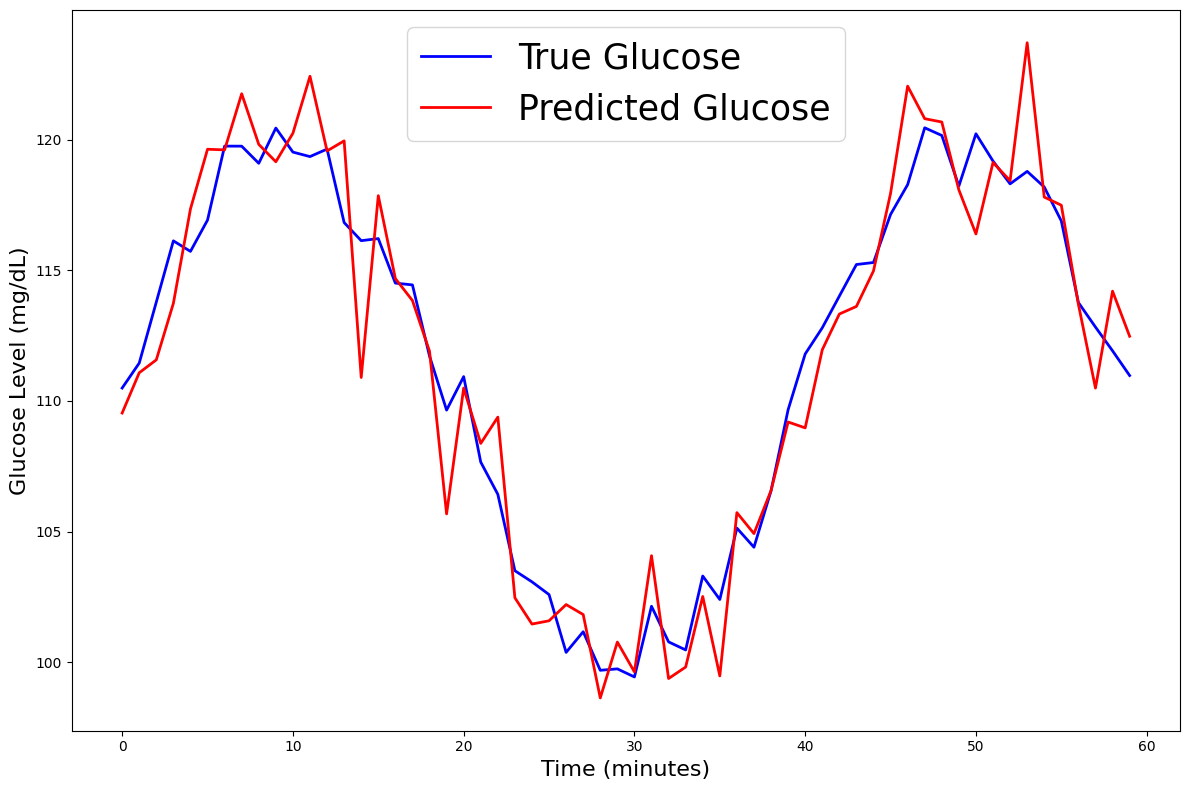

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Time axis: 60 minutes
time = np.arange(60)

# True glucose values: base + slight variation
true_glucose = 110 + np.sin(np.linspace(0, 3 * np.pi, 60)) * 10 + np.random.normal(0, 1, 60)

# Predicted glucose values: close to true values with small error
predicted_glucose = true_glucose + np.random.normal(0, 2, 60)

# Plotting
plt.figure(figsize=(12, 8))
plt.plot(time, true_glucose, label='True Glucose', color='blue', linewidth=2)
plt.plot(time, predicted_glucose, label='Predicted Glucose', color='red', linewidth=2)

# Enlarged and centered title and labels
plt.xlabel('Time (minutes)', fontsize=16)
plt.ylabel('Glucose Level (mg/dL)', fontsize=16)

# Larger legend
plt.legend(fontsize=25, loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=1)

# Grid and layout
plt.tight_layout()

# Show plot
plt.show()

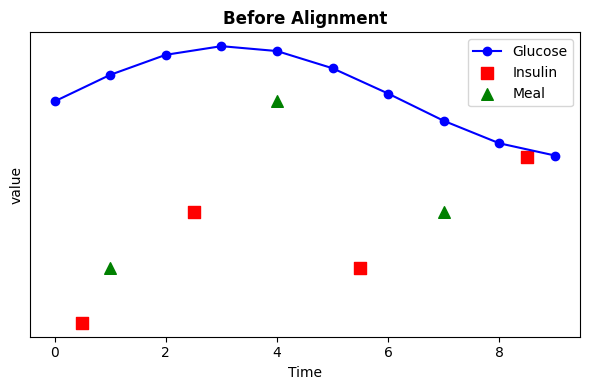

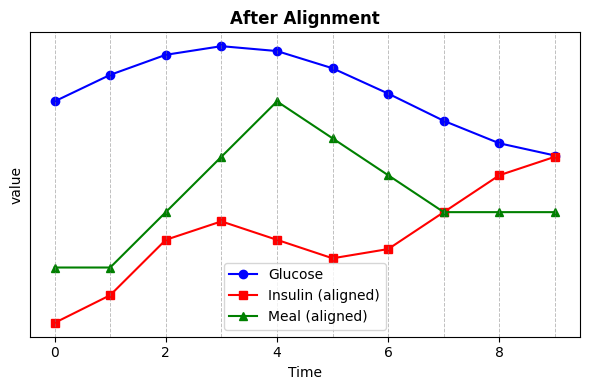

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 构造示例时间序列
time_glucose = np.arange(0, 10)
glucose = np.sin(time_glucose/2) + 5   # 血糖曲线（连续）

time_insulin = np.array([0.5, 2.5, 5.5, 8.5])  # 胰岛素（稀疏/错位）
insulin = np.array([1, 3, 2, 4])

time_meal = np.array([1, 4, 7])               # 进食（稀疏/错位）
meal = np.array([2, 5, 3])

# 第一幅图：对齐前
plt.figure(figsize=(6, 4))
plt.plot(time_glucose, glucose, "-o", label="Glucose", color="blue")
plt.scatter(time_insulin, insulin, c="red", marker="s", s=70, label="Insulin")
plt.scatter(time_meal, meal, c="green", marker="^", s=70, label="Meal")
plt.title("Before Alignment", fontsize=12, weight="bold")
plt.xlabel("Time")
plt.ylabel("value")
plt.yticks([])  # 隐藏y轴刻度
plt.legend()
plt.tight_layout()
plt.show()

# 第二幅图：对齐后（插值对齐，并加虚线）
aligned_time = np.arange(0, 10)
aligned_insulin = np.interp(aligned_time, time_insulin, insulin)
aligned_meal = np.interp(aligned_time, time_meal, meal)

plt.figure(figsize=(6, 4))
plt.plot(time_glucose, glucose, "-o", label="Glucose", color="blue")
plt.plot(aligned_time, aligned_insulin, "-s", c="red", label="Insulin (aligned)")
plt.plot(aligned_time, aligned_meal, "-^", c="green", label="Meal (aligned)")
for t in aligned_time:
    plt.axvline(x=t, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
plt.title("After Alignment", fontsize=12, weight="bold")
plt.xlabel("Time")
plt.ylabel("value")
plt.yticks([])  # 隐藏y轴刻度
plt.legend()
plt.tight_layout()
plt.show()

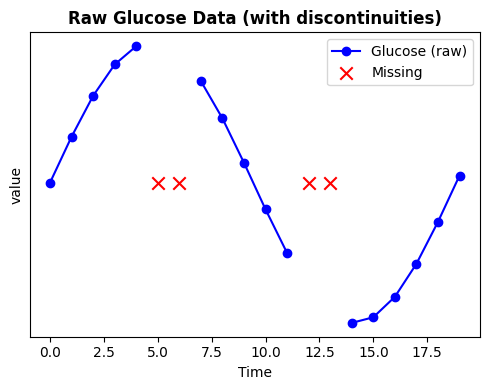

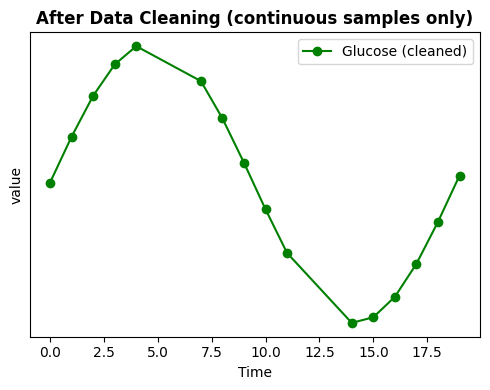

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 构造示例血糖数据（包含缺失）
time = np.arange(0, 20)
glucose = np.sin(time/3) + 5
glucose[[5, 6, 12, 13]] = np.nan  # 模拟缺失点

# --- 左图：原始数据，带缺失 ---
fig1, ax1 = plt.subplots(figsize=(5, 4))
ax1.plot(time, glucose, "-o", color="blue", label="Glucose (raw)")
missing_idx = np.where(np.isnan(glucose))[0]
ax1.scatter(time[missing_idx], [5]*len(missing_idx), marker="x", c="red", s=80, label="Missing")
ax1.set_title("Raw Glucose Data (with discontinuities)", fontsize=12, weight="bold")
ax1.set_xlabel("Time")
ax1.set_ylabel("value")  # y轴命名为value
ax1.legend()
ax1.set_yticklabels([])  # 不显示y轴数值
plt.yticks([]) 
plt.tight_layout()
plt.show()

# --- 右图：清理后（去掉含缺失的段）---
fig2, ax2 = plt.subplots(figsize=(5, 4))
mask = ~np.isnan(glucose)
ax2.plot(time[mask], glucose[mask], "-o", color="green", label="Glucose (cleaned)")
ax2.set_title("After Data Cleaning (continuous samples only)", fontsize=12, weight="bold")
ax2.set_xlabel("Time")
ax2.set_ylabel("value")  # y轴命名为value
ax2.legend()
ax2.set_yticklabels([])  # 不显示y轴数值
plt.yticks([]) 
plt.tight_layout()
plt.show()

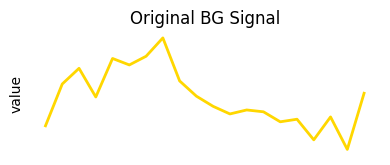

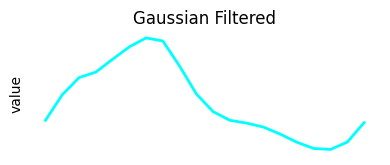

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# 生成模拟数据
x = np.linspace(0, 5, 20)
original_signal = np.sin(x) + np.random.normal(0, 0.5, x.shape)
smoothed_signal = gaussian_filter1d(original_signal, sigma=1)

# 颜色适配紫色底（推荐亮色系）
line_color = "#FFD700"  # 金色
smooth_color = "#00FFFF"  # 青色

# 原始信号图
fig1, ax1 = plt.subplots(figsize=(4, 1.75)) 
ax1.plot(x, original_signal, color=line_color, linewidth=2)
ax1.set_title('Original BG Signal', color='black')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_frame_on(False)
fig1.patch.set_alpha(0.0)
ax1.patch.set_alpha(0.0)
ax1.set_ylabel('value', color='black')
plt.tight_layout()
# plt.savefig('original_signal.png', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

# 平滑信号图
fig2, ax2 = plt.subplots(figsize=(4, 1.75)) 
ax2.plot(x, smoothed_signal, color=smooth_color, linewidth=2)
ax2.set_title('Gaussian Filtered', color='black')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_frame_on(False)
fig2.patch.set_alpha(0.0)
ax2.patch.set_alpha(0.0)
ax2.set_ylabel('value', color='black')
plt.tight_layout()
# plt.savefig('smoothed_signal.png', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()